## Part 1: Load and Explore the Fashion-MNIST Dataset

Fashion-MNIST is a dataset of grayscale images belonging to 10 different clothing and footwear categories. Each image has a size of 28 × 28 pixels.

The dataset is divided into training and test sets. The training data is used to train the CNN models, while the test data is used to evaluate their performance on unseen images.

The dataset is loaded using TensorFlow/Keras, and the class names are defined to map the numerical labels to their corresponding categories.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Display the shapes of the datasets
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

# Define class names
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# Display number of classes
print("Number of classes:", len(class_names))

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


### Dataset Shape

The loaded dataset contains 60,000 training images and 10,000 test images. Each image has dimensions of 28 × 28 pixels and is grayscale.

The training labels and test labels contain one class label for each corresponding image.

The dataset contains 10 different classes:

- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot

### Visualizing Sample Images from Each Class

To understand the Fashion-MNIST dataset visually, one sample image from each of the 10 classes is displayed below. Each image is labeled with its corresponding class name.

This helps us observe the visual differences and similarities between the different clothing and footwear categories before applying preprocessing and training the CNN models.

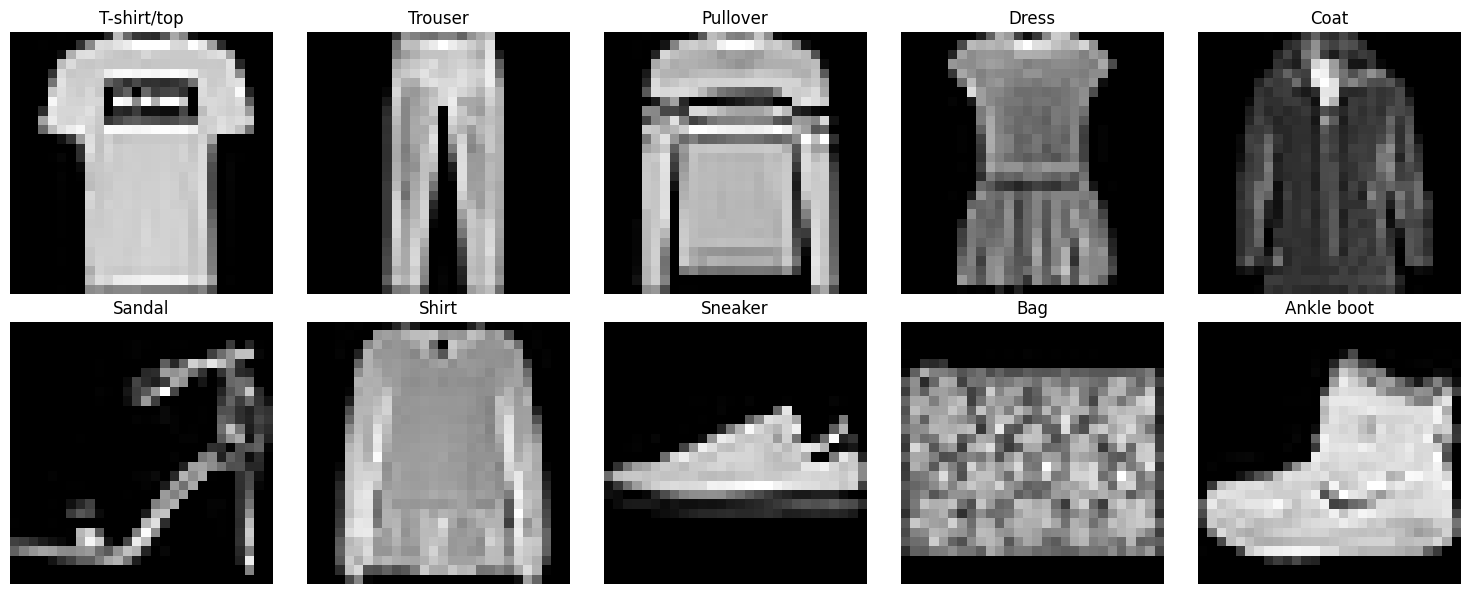

In [5]:
# Display one sample image from each class

plt.figure(figsize=(15, 6))

for class_id in range(10):
    # Find the first image belonging to the current class
    index = np.where(y_train == class_id)[0][0]
    
    # Display the image
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(x_train[index], cmap="gray")
    plt.title(class_names[class_id])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Normalizing Image Pixel Values

The original Fashion-MNIST pixel values range from 0 to 255, where 0 represents black and higher values represent lighter shades.

To make the input values more suitable for neural network training, the pixel values are normalized to the range 0 to 1 by dividing each pixel value by 255.

Normalization puts the input features on a smaller and consistent scale, which helps the neural network train more efficiently and stably.

In [6]:
# Normalize pixel values from 0-255 to 0-1

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [7]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Normalization Result

The minimum pixel value after normalization is 0.0 and the maximum is 1.0. This confirms that the original pixel values, which ranged from 0 to 255, have been successfully scaled to the range 0 to 1.

This normalized representation provides smaller and consistently scaled input values for the CNN, helping the neural network train more efficiently and stably.

### Reshaping Images for CNN Input

The Fashion-MNIST images are originally stored with the shape `(number of images, 28, 28)`. Since the images are grayscale, a channel dimension of 1 must be added so that they have the four-dimensional structure expected by a 2D convolutional layer.

The images are therefore reshaped to `(number of images, 28, 28, 1)`, where the dimensions represent the number of images, height, width, and number of channels respectively.

In [8]:
# Add the channel dimension for CNN input

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Check the new shapes
print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape : (10000, 28, 28, 1)


### Reshaping Result

The training images now have the shape `(60000, 28, 28, 1)` and the test images have the shape `(10000, 28, 28, 1)`.

The four dimensions represent:

- Number of images
- Image height
- Image width
- Number of channels

Since Fashion-MNIST contains grayscale images, the number of channels is 1. The reshaped data is now in the appropriate format for processing with `Conv2D` layers.

### Why is Normalization Required for Image Data?

Normalization scales the original pixel values from the range 0–255 to the range 0–1. This provides the neural network with smaller and consistently scaled input values.

Normalized inputs help the CNN train more efficiently and stably, making the optimization process easier compared with using the original 0–255 pixel values.

### Why Do CNNs Require Reshaped Image Inputs?

CNNs process images using spatial dimensions such as height and width, along with a channel dimension. The original Fashion-MNIST images have the shape `(28, 28)`, which represents height and width but does not explicitly include the image channel.

Since Fashion-MNIST images are grayscale, a channel dimension of 1 is added, changing the shape to `(28, 28, 1)` for each image. For the complete training and test datasets, the shapes become `(60000, 28, 28, 1)` and `(10000, 28, 28, 1)` respectively.

This format allows the images to be used as input to `Conv2D` layers.

## Part 2: Build and Train a Shallow CNN

A shallow Convolutional Neural Network is designed for the Fashion-MNIST classification task. The model contains two convolutional layers, one max-pooling layer, one fully connected hidden layer, and a 10-neuron output layer.

The convolutional layers are used to learn visual features from the input images. A max-pooling layer reduces the spatial dimensions of the extracted feature maps. The Flatten layer converts the feature maps into a one-dimensional vector, which is then passed to a dense hidden layer for classification.

The final output layer contains 10 neurons with softmax activation because Fashion-MNIST contains 10 classes.

In [9]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Build the shallow CNN
shallow_model = Sequential([
    
    # First convolutional layer
    Conv2D(32, (3, 3), padding="same", activation="relu",
           input_shape=(28, 28, 1)),
    
    # Second convolutional layer
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    
    # One pooling layer
    MaxPooling2D((2, 2)),
    
    # Convert feature maps into a 1D vector
    Flatten(),
    
    # One dense hidden layer
    Dense(128, activation="relu"),
    
    # Output layer: 10 Fashion-MNIST classes
    Dense(10, activation="softmax")
])

# Display the model architecture
shallow_model.summary()

/Users/mrudulmukundan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,866 (6.20 MB)

 Trainable params: 1,625,866 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

### Shallow CNN Architecture Summary

The shallow CNN consists of two convolutional layers followed by one max-pooling layer, a Flatten layer, one dense hidden layer, and a 10-neuron output layer.

The first convolutional layer uses 32 filters of size 3 × 3, while the second convolutional layer uses 64 filters of the same size. The max-pooling layer reduces the spatial dimensions of the feature maps from 28 × 28 to 14 × 14.

The Flatten layer converts the resulting 14 × 14 × 64 feature maps into a one-dimensional vector containing 12,544 values. This vector is passed to a dense layer containing 128 neurons. The final output layer contains 10 neurons with softmax activation, corresponding to the 10 Fashion-MNIST classes.

The model contains a total of 1,625,866 trainable parameters.

### Compiling the Shallow CNN

Before training the CNN, the model is compiled by specifying a loss function, an optimizer, and an evaluation metric.

Since Fashion-MNIST is a multi-class classification problem with integer class labels, `sparse_categorical_crossentropy` is used as the loss function. The Adam optimizer is used to update the model's trainable parameters during training, and accuracy is used as the main performance metric.

In [10]:
# Compile the shallow CNN

shallow_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history_shallow = shallow_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.8089 - loss: 0.5317 - val_accuracy: 0.9060 - val_loss: 0.2620
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9137 - loss: 0.2381 - val_accuracy: 0.9078 - val_loss: 0.2478
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.9360 - loss: 0.1777 - val_accuracy: 0.9231 - val_loss: 0.2189
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.9509 - loss: 0.1364 - val_accuracy: 0.9200 - val_loss: 0.2258
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.9643 - loss: 0.1020 - val_accuracy: 0.9196 - val_loss: 0.2473
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - accuracy: 0.9761 - loss: 0.0700 - val_accuracy: 0.9206 - val_loss: 0.2554
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.9817 - loss: 0.0524 - val_accuracy: 0.9222 - val_loss: 0.2981
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.9880 - loss: 0.0366 - 

### Shallow CNN Training Observations

The Shallow CNN showed strong learning performance during training. Training accuracy increased from 80.89% in the first epoch to 99.24% by the tenth epoch, while training loss decreased from 0.5317 to 0.0240.

Validation accuracy improved during the early epochs and reached a maximum of 92.38% at epoch 10. However, validation loss reached its lowest value of 0.2189 at epoch 3 and then generally increased during the later epochs.

The increasing gap between training and validation performance, together with the rising validation loss while training loss continued to decrease, indicates signs of overfitting in the later stages of training. The model does not appear to suffer from underfitting because its training accuracy became very high.

### Training and Validation Curves

The training history is visualized using accuracy and loss curves. Training accuracy and validation accuracy are plotted to evaluate the model's learning and generalization performance. Training loss and validation loss are also plotted to identify potential signs of overfitting or underfitting.

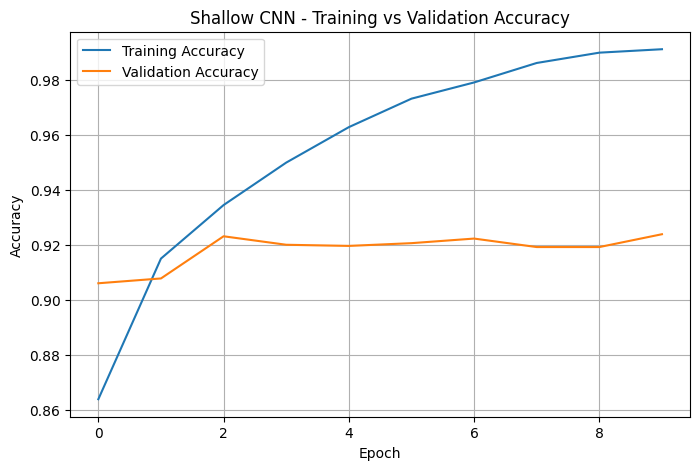

In [12]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history_shallow.history["accuracy"], label="Training Accuracy")
plt.plot(history_shallow.history["val_accuracy"], label="Validation Accuracy")

plt.title("Shallow CNN - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

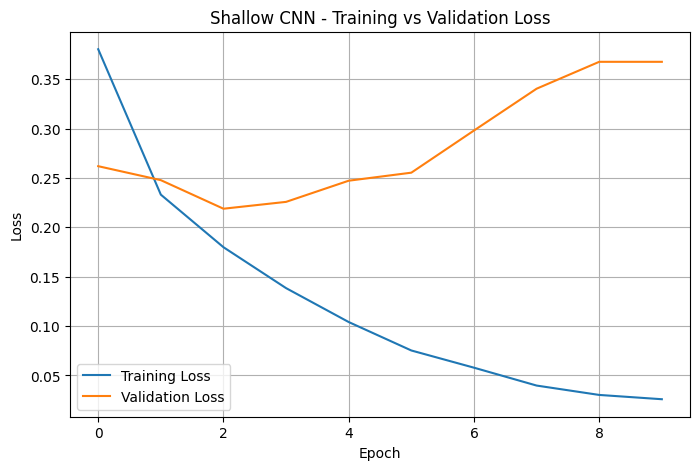

In [13]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history_shallow.history["loss"], label="Training Loss")
plt.plot(history_shallow.history["val_loss"], label="Validation Loss")

plt.title("Shallow CNN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Overfitting and Underfitting Analysis

The Shallow CNN does not show signs of underfitting because its training accuracy increases to 99.24% and its training loss decreases to 0.0240 by the final epoch.

However, the model shows signs of overfitting during the later epochs. Training accuracy continues to increase while validation accuracy remains around 92%. At the same time, training loss continues to decrease, whereas validation loss reaches its minimum of 0.2189 at epoch 3 and then increases to 0.3677 by epoch 10.

The growing difference between training and validation performance indicates that the model is learning the training data very well but is not achieving similar improvements on unseen validation data.

### Evaluating the Shallow CNN on the Test Set

After training, the Shallow CNN is evaluated on the separate test dataset. The test set contains images that were not used during model training or validation.

The test accuracy provides a final measure of how well the trained CNN can classify previously unseen Fashion-MNIST images.

In [14]:
# Evaluate the shallow CNN on the test set

test_loss, test_accuracy = shallow_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Shallow CNN Test Loss:", test_loss)
print("Shallow CNN Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9226 - loss: 0.3884
Shallow CNN Test Loss: 0.3921244740486145
Shallow CNN Test Accuracy: 0.9235000014305115


### Shallow CNN Test Evaluation

The trained Shallow CNN was evaluated on the separate Fashion-MNIST test set. The model achieved a test loss of approximately 0.3921 and a test accuracy of approximately 92.35%.

This indicates that the model correctly classified about 92.35% of the previously unseen test images. The test accuracy is very close to the validation accuracy, suggesting that the model generalizes to the test set at a similar level as observed during validation.

### Expected Patterns Learned by a Shallow CNN

A shallow CNN is expected to learn relatively simple and low-level visual patterns from Fashion-MNIST images. The early convolutional layers can learn features such as edges, lines, curves, corners, and simple textures.

The deeper convolutional layer can combine these basic features to learn somewhat more complex shapes and structures. However, because the network has relatively few convolutional layers, its ability to learn highly complex and hierarchical representations is more limited than that of a deeper CNN.

## Part 3: Build and Train a Deep CNN

A deeper Convolutional Neural Network is designed to provide greater capacity for learning hierarchical visual representations from the Fashion-MNIST images.

The Deep CNN contains four convolutional layers with increasing numbers of filters, three max-pooling layers, a Flatten layer, one dense hidden layer, and a 10-neuron softmax output layer.

The convolutional layers use 32, 64, 128, and 256 filters respectively. Multiple pooling layers progressively reduce the spatial dimensions of the feature maps while retaining important information.

Compared with the Shallow CNN, this architecture has more convolutional layers, more pooling layers, and a larger number of filters, allowing it to learn potentially more complex visual representations.

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

# Build the deep CNN
deep_model = Sequential([
    
    # Input image: 28 × 28 grayscale
    Input(shape=(28, 28, 1)),
    
    # First convolutional block
    Conv2D(32, (3, 3), padding="same", activation="relu"),
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Second convolutional block
    Conv2D(128, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Third convolutional block
    Conv2D(256, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Convert feature maps into a 1D vector
    Flatten(),
    
    # Dense hidden layer
    Dense(128, activation="relu"),
    
    # Output layer: 10 Fashion-MNIST classes
    Dense(10, activation="softmax")
])

# Display the model architecture
deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,170 (2.61 MB)

 Trainable params: 684,170 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

### Deep CNN Architecture Summary

The Deep CNN contains four convolutional layers with 32, 64, 128, and 256 filters respectively, along with three max-pooling layers. The spatial dimensions are progressively reduced from 28 × 28 to 14 × 14, then 7 × 7, and finally 3 × 3.

After the final pooling layer, the 3 × 3 × 256 feature maps are flattened into 2,304 values and passed to a dense layer containing 128 neurons. The final output layer contains 10 neurons with softmax activation for the 10 Fashion-MNIST classes.

The model contains 684,170 trainable parameters. Interestingly, although the Deep CNN has more convolutional layers and filters than the Shallow CNN, it has fewer total parameters. This is mainly because the multiple pooling layers significantly reduce the spatial dimensions before the Flatten and Dense layers.

### Compiling the Deep CNN

The Deep CNN is compiled using the Adam optimizer, sparse categorical cross-entropy loss, and accuracy as the evaluation metric. The same compilation settings used for the Shallow CNN are retained so that the two architectures can be compared under similar training conditions.

In [16]:
# Compile the deep CNN

deep_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Training the Deep CNN

The Deep CNN is trained on the Fashion-MNIST training dataset using 10 epochs and a batch size of 64. Twenty percent of the training data is reserved for validation.

The same training settings used for the Shallow CNN are maintained so that the performance of the two architectures can be compared fairly.

In [17]:
# Train the deep CNN

history_deep = deep_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 53s 70ms/step - accuracy: 0.7434 - loss: 0.6993 - val_accuracy: 0.8952 - val_loss: 0.2948
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 57s 76ms/step - accuracy: 0.9000 - loss: 0.2757 - val_accuracy: 0.9110 - val_loss: 0.2476
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 79ms/step - accuracy: 0.9183 - loss: 0.2178 - val_accuracy: 0.9147 - val_loss: 0.2405
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 79ms/step - accuracy: 0.9334 - loss: 0.1830 - val_accuracy: 0.9218 - val_loss: 0.2146
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 60s 80ms/step - accuracy: 0.9454 - loss: 0.1485 - val_accuracy: 0.9131 - val_loss: 0.2402
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - accuracy: 0.9550 - loss: 0.1207 - val_accuracy: 0.9123 - val_loss: 0.2595
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - accuracy: 0.9640 - loss: 0.1001 - val_accuracy: 0.9247 - val_loss: 0.2224
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 62s 82ms/step - accuracy: 0.9728 - loss: 0.0738 - 

### Deep CNN Training Observations

The Deep CNN showed strong learning performance during training. Training accuracy increased from 74.34% in the first epoch to 98.08% by the tenth epoch, while training loss decreased from 0.6993 to 0.0530.

Validation accuracy improved during training and reached a maximum of 92.61% at epoch 9. The lowest validation loss was 0.2146 at epoch 4. After the validation loss reached its minimum, it generally increased while training loss continued to decrease.

This indicates signs of overfitting during the later stages of training. However, the Deep CNN achieved a slightly higher validation accuracy than the Shallow CNN, although the improvement is relatively small. The Deep CNN also required more training time in this experiment.

### Training and Validation Curves

The training history of the Deep CNN is visualized using accuracy and loss curves. Training and validation accuracy are compared to evaluate learning and generalization, while training and validation loss are compared to identify signs of overfitting or underfitting.

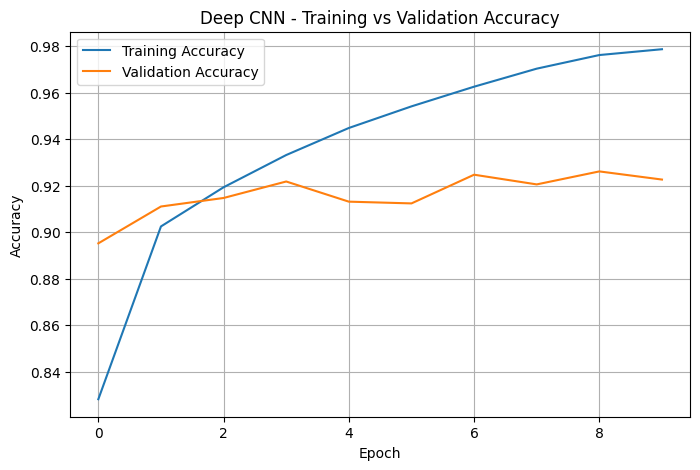

In [18]:
# Plot Deep CNN training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history_deep.history["accuracy"], label="Training Accuracy")
plt.plot(history_deep.history["val_accuracy"], label="Validation Accuracy")

plt.title("Deep CNN - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

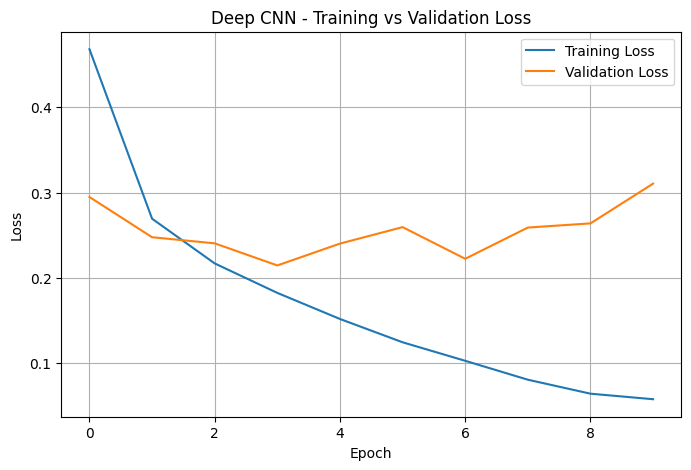

In [20]:
# Plot Deep CNN training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history_deep.history["loss"], label="Training Loss")
plt.plot(history_deep.history["val_loss"], label="Validation Loss")

plt.title("Deep CNN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Deep CNN Learning Curve Analysis

The Deep CNN training and validation curves show that training accuracy steadily increases to 98.08%, while validation accuracy remains around 91–93%. The best validation accuracy is 92.61%, achieved at epoch 9.

The training loss continuously decreases from 0.6993 to 0.0530. In contrast, validation loss reaches its lowest value of 0.2146 at epoch 4 and then generally increases, reaching 0.3105 by epoch 10.

The increasing difference between training and validation performance, together with the increase in validation loss during later epochs, indicates that the Deep CNN shows signs of overfitting.

### Evaluating the Deep CNN on the Test Set

The trained Deep CNN is evaluated on the separate Fashion-MNIST test set. Since the test images were not used during training, the test accuracy provides a final measure of the model's ability to generalize to unseen images.

In [21]:
# Evaluate the Deep CNN on the test set

deep_test_loss, deep_test_accuracy = deep_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Deep CNN Test Loss:", deep_test_loss)
print("Deep CNN Test Accuracy:", deep_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9236 - loss: 0.3090
Deep CNN Test Loss: 0.325355589389801
Deep CNN Test Accuracy: 0.9176999926567078


### Additional Patterns Learned by a Deep CNN

A Deep CNN can learn more complex and hierarchical visual representations than a shallow CNN. Earlier convolutional layers can learn basic features such as edges, lines, curves, and textures. Deeper layers can combine these low-level features into more complex shapes, object parts, and higher-level visual structures.

For Fashion-MNIST, the deeper layers may potentially learn more detailed combinations of features related to garment shapes, footwear structures, boundaries, and other class-specific visual patterns.

### Did the Deeper Model Improve Performance Meaningfully?

The deeper model did not improve the final test performance meaningfully in this experiment. The Shallow CNN achieved a test accuracy of 92.35%, while the Deep CNN achieved 91.77%, which is 0.58 percentage points lower.

Although the Deep CNN achieved a slightly higher best validation accuracy of 92.61% compared with approximately 92.38% for the Shallow CNN, this improvement did not transfer to the test set. The Deep CNN also required considerably more training time and showed signs of overfitting during the later epochs.

Therefore, for this experiment, the Shallow CNN provided better test accuracy with a simpler architecture and lower training cost.